In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
!cp -r "/content/drive/MyDrive/ai_ml_datasets/crop_recommendation" /content/crop_recommendation


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [38]:
df=pd.read_csv("/content/crop_recommendation/crop_recommendation_dataset.csv")
df


,Temperature,Humidity,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop
0,20.879744,82.002744,202.935536,6.502985,69.3000,79.50000,94.4400,0.63,Loamy Soil,rice
1,21.770462,80.319644,226.655537,7.038096,72.0200,141.82400,141.6978,1.40,Loamy Soil,rice
2,23.004459,82.320763,263.964248,7.633568,77.7700,59.39000,81.8900,1.80,Peaty Soil,rice
3,26.491096,80.283629,242.864034,6.980401,78.6500,147.45895,142.9430,1.43,Loamy Soil,rice
4,20.280071,81.604873,262.717340,7.628473,73.9800,68.95000,95.7400,1.75,Peaty Soil,rice
...,...,...,...,...,...,...,...,...,...,...
3095,25.287846,89.636679,58.286977,6.765095,57.3400,144.48000,73.0800,1.64,Neutral Soil,watermelon
3096,26.638386,84.695469,48.324286,6.189214,56.0600,61.34000,47.9500,1.35,Peaty Soil,watermelon
3097,25.331045,84.305338,41.532187,6.904242,54.9395,145.53795,97.8300,1.58,Neutral Soil,watermelon
3098,26.820601,83.892415,43.971937,6.463271,55.5100,76.89000,50.9200,0.68,Acidic Soil,watermelon


In [39]:
df.columns

Index(['Temperature', 'Humidity', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous',
       'Potassium', 'Carbon', 'Soil', 'Crop'],
      dtype='object')

In [40]:
df.dtypes

,0
Temperature,float64
Humidity,float64
Rainfall,float64
PH,float64
Nitrogen,float64
Phosphorous,float64
Potassium,float64
Carbon,float64
Soil,object
Crop,object


In [41]:
# To see if a column contains null value
df.isnull().any()

,0
Temperature,False
Humidity,False
Rainfall,False
PH,False
Nitrogen,False
Phosphorous,False
Potassium,False
Carbon,False
Soil,False
Crop,False


In [42]:
# count the no of null value each column  contains
df.isnull().sum()

,0
Temperature,0
Humidity,0
Rainfall,0
PH,0
Nitrogen,0
Phosphorous,0
Potassium,0
Carbon,0
Soil,0
Crop,0


In [43]:
df.head()

,Temperature,Humidity,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop
0,20.879744,82.002744,202.935536,6.502985,69.30,79.50000,94.4400,0.63,Loamy Soil,rice
1,21.770462,80.319644,226.655537,7.038096,72.02,141.82400,141.6978,1.40,Loamy Soil,rice
2,23.004459,82.320763,263.964248,7.633568,77.77,59.39000,81.8900,1.80,Peaty Soil,rice
3,26.491096,80.283629,242.864034,6.980401,78.65,147.45895,142.9430,1.43,Loamy Soil,rice
4,20.280071,81.604873,262.717340,7.628473,73.98,68.95000,95.7400,1.75,Peaty Soil,rice


In [44]:
# To see the unique values of each soil and crop column
print(df['Soil'].unique())
print(df['Crop'].unique())

['Loamy Soil' 'Peaty Soil' 'Acidic Soil' 'Neutral Soil' 'Alkaline Soil']
['rice' 'wheat' 'Mung Bean' 'Tea' 'millet' 'maize' 'Lentil' 'Jute'
 'Coffee' 'Cotton' 'Ground Nut' 'Peas' 'Rubber' 'Sugarcane' 'Tobacco'
 'Kidney Beans' 'Moth Beans' 'Coconut' 'Black gram' 'Adzuki Beans'
 'Pigeon Peas' 'Chickpea' 'banana' 'grapes' 'apple' 'mango' 'muskmelon'
 'orange' 'papaya' 'pomegranate' 'watermelon']


In [45]:
df['Crop'].value_counts()

,count
Crop,
rice,100
wheat,100
Mung Bean,100
Tea,100
millet,100
maize,100
Lentil,100
Jute,100
Coffee,100


In [46]:
x=df.drop("Crop",axis=1)
y=df["Crop"]

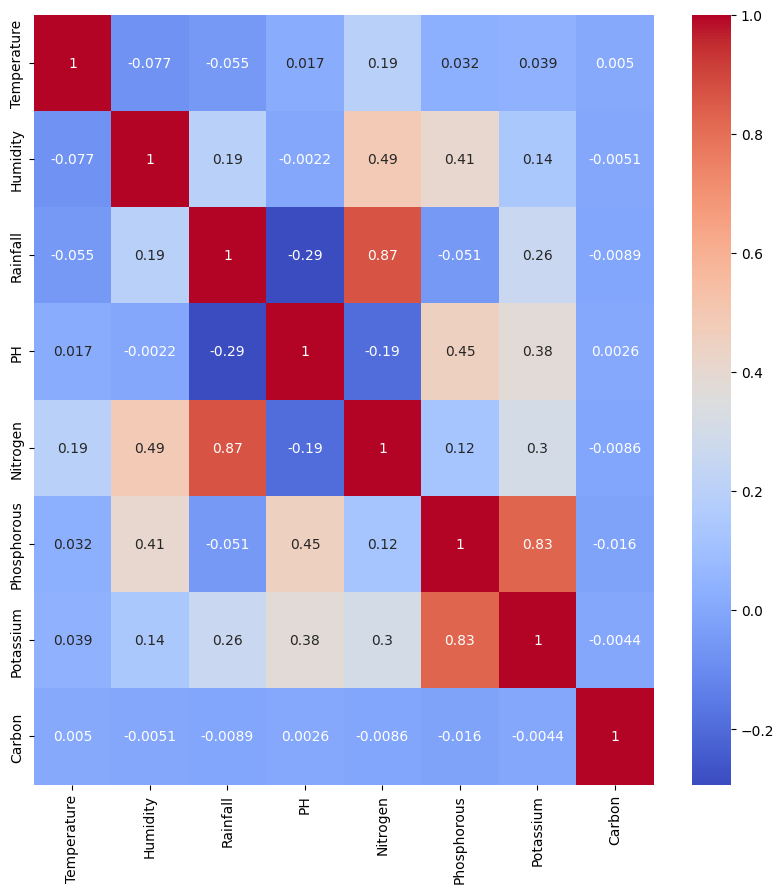

In [47]:
# To show the correlation between each column using heat map
plt.figure(figsize=(10,10))
numeric_df = df.select_dtypes(include='number')  # only numeric columns
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [48]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [49]:
# Encode target labels to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_encoded

array([28, 28, 28, ..., 29, 29, 29])

In [50]:
scaler = StandardScaler()

In [51]:
df.head()

,Temperature,Humidity,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop
0,20.879744,82.002744,202.935536,6.502985,69.30,79.50000,94.4400,0.63,Loamy Soil,rice
1,21.770462,80.319644,226.655537,7.038096,72.02,141.82400,141.6978,1.40,Loamy Soil,rice
2,23.004459,82.320763,263.964248,7.633568,77.77,59.39000,81.8900,1.80,Peaty Soil,rice
3,26.491096,80.283629,242.864034,6.980401,78.65,147.45895,142.9430,1.43,Loamy Soil,rice
4,20.280071,81.604873,262.717340,7.628473,73.98,68.95000,95.7400,1.75,Peaty Soil,rice


In [52]:
x_encoded = x.copy()
# Encode 'Soil Type' column
x_encoded['Soil'] = x_encoded['Soil'].astype('category').cat.codes

# Now scale
x_scaled = scaler.fit_transform(x_encoded)
x_scaled


array([[-0.82518456,  0.66676662,  1.4514321 , ...,  0.84476134,
        -1.46966558,  0.29999266],
       [-0.7071174 ,  0.59661703,  1.82272921, ...,  2.44890336,
        -0.13529318,  0.29999266],
       [-0.54354757,  0.68002126,  2.40673492, ...,  0.41875797,
         0.55788729,  1.54078954],
       ...,
       [-0.23515215,  0.76273597, -1.07506847, ...,  0.95983317,
         0.17663804,  0.9203911 ],
       [-0.03770733,  0.74552583, -1.03687825, ..., -0.63250296,
        -1.38301802, -0.94080421],
       [-0.03770733,  0.97565258, -0.80870226, ..., -0.64472297,
         0.02067243, -0.94080421]])

In [53]:
y_encoded

array([28, 28, 28, ..., 29, 29, 29])

,Temperature,Humidity,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop
0,20.879744,82.002744,202.935536,6.502985,69.3000,79.50000,94.4400,0.63,Loamy Soil,rice
1,21.770462,80.319644,226.655537,7.038096,72.0200,141.82400,141.6978,1.40,Loamy Soil,rice
2,23.004459,82.320763,263.964248,7.633568,77.7700,59.39000,81.8900,1.80,Peaty Soil,rice
3,26.491096,80.283629,242.864034,6.980401,78.6500,147.45895,142.9430,1.43,Loamy Soil,rice
4,20.280071,81.604873,262.717340,7.628473,73.9800,68.95000,95.7400,1.75,Peaty Soil,rice
...,...,...,...,...,...,...,...,...,...,...
3095,25.287846,89.636679,58.286977,6.765095,57.3400,144.48000,73.0800,1.64,Neutral Soil,watermelon
3096,26.638386,84.695469,48.324286,6.189214,56.0600,61.34000,47.9500,1.35,Peaty Soil,watermelon
3097,25.331045,84.305338,41.532187,6.904242,54.9395,145.53795,97.8300,1.58,Neutral Soil,watermelon
3098,26.820601,83.892415,43.971937,6.463271,55.5100,76.89000,50.9200,0.68,Acidic Soil,watermelon


In [55]:
# train test split
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    x_scaled, y_encoded, test_size=0.2, random_state=42
)

In [56]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [57]:
# Calculate the number of unique crop classes from the LabelEncoder
num_classes = len(le.classes_)
num_classes

31

In [58]:
model = Sequential([
    Dense(128, input_dim=X_train.shape[1], activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.1),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')  # Multi-class output
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
model.compile(
    optimizer='RMSprop',
    loss='sparse_categorical_crossentropy',  # use sparse since labels are integers
    metrics=['accuracy']
)

In [60]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 31)             │         3,999 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,327 (278.62 KB)

 Trainable params: 71,327 (278.62 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
EPOCHS = 100

In [62]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=50
)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.1251 - loss: 3.1210 - val_accuracy: 0.3387 - val_loss: 1.9591
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4465 - loss: 1.6679 - val_accuracy: 0.5766 - val_loss: 1.2215
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5493 - loss: 1.2564 - val_accuracy: 0.5544 - val_loss: 1.1049
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6057 - loss: 1.0484 - val_accuracy: 0.6391 - val_loss: 0.9347
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6421 - loss: 0.9528 - val_accuracy: 0.7077 - val_loss: 0.7662
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6482 - loss: 0.8891 - val_accuracy: 0.7097 - val_loss: 0.7926
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6900 - loss: 0.7947 - val_accuracy: 0.7077 - val_loss: 0.7582
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7290 - loss: 0.7716 - val_accuracy: 0.7359 - 

In [63]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8874 - loss: 0.3294 
Test Accuracy: 89.35%


In [64]:
history.params

{'verbose': 'auto', 'epochs': 100, 'steps': 40}

In [65]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [66]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

print("accuracy",acc)
print("validation accuracy",val_acc)
print("loss",loss)
print("validation loss",val_loss)

accuracy [0.21169355511665344, 0.47429436445236206, 0.5519153475761414, 0.600806474685669, 0.6345766186714172, 0.6658266186714172, 0.6875, 0.711693525314331, 0.7147177457809448, 0.7303427457809448, 0.7615927457809448, 0.7671371102333069, 0.7631048560142517, 0.7706653475761414, 0.7893145084381104, 0.7827621102333069, 0.8004032373428345, 0.7973790168762207, 0.8150201439857483, 0.8109878897666931, 0.8155242204666138, 0.8235887289047241, 0.8230846524238586, 0.8235887289047241, 0.8356854915618896, 0.8462701439857483, 0.8497983813285828, 0.836693525314331, 0.8543346524238586, 0.8377016186714172, 0.8538306355476379, 0.8583669066429138, 0.8432459831237793, 0.8669354915618896, 0.8462701439857483, 0.8654233813285828, 0.8744959831237793, 0.8573588728904724, 0.8810483813285828, 0.8850806355476379, 0.8805443644523621, 0.8744959831237793, 0.8724798560142517, 0.8850806355476379, 0.8916330933570862, 0.8790322542190552, 0.8825604915618896, 0.8896169066429138, 0.8855846524238586, 0.8770161271095276, 0.8

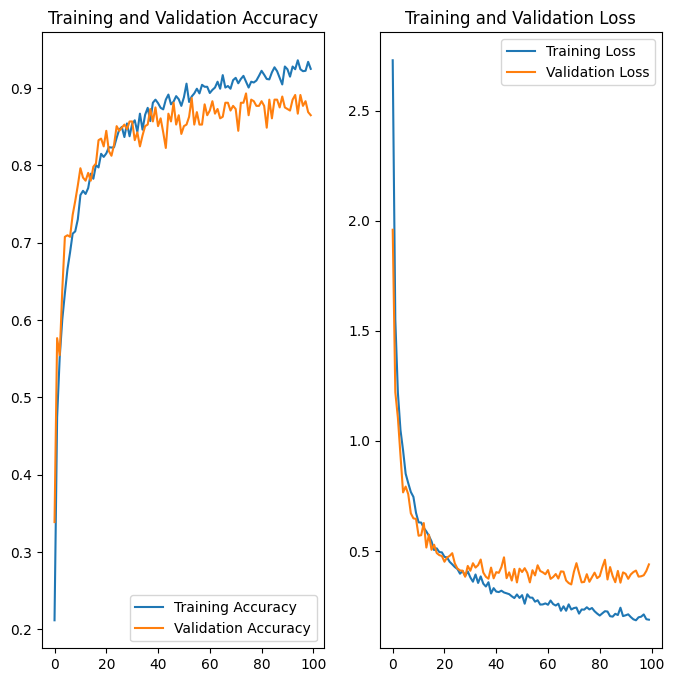

In [67]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS),acc,label='Training Accuracy')
plt.plot(range(EPOCHS),val_acc,label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(range(EPOCHS),loss,label='Training Loss')
plt.plot(range(EPOCHS),val_loss,label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [68]:
# Save the model in h5 format in /content/drive/MyDrive/ai_ml_model
model.save("/content/drive/MyDrive/ai_ml_model/crop_recommendation_model.h5")